# PTB-XL Multi-Sample ECG Analysis

## Objective

The goal of this analysis is to extend the previous single-record ECG exploration to multiple ECG records.

Five ECG records with different diagnostic labels will be compared using the same R-peak detection parameters. The purpose is to test whether a fixed R-peak detection threshold works consistently across different ECG signals.

The diagnostic labels used in this analysis come from the PTB-XL dataset metadata and are not diagnoses made from my own visual interpretation.

In [2]:
# Install the ECG library
!pip install wfdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import wfdb
import ast



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 46.0 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.


In [3]:
# Load PTB-XL metadata
metadata = pd.read_csv(
    "https://physionet.org/files/ptb-xl/1.0.3/ptbxl_database.csv",
    index_col="ecg_id"
)

metadata.head()

,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


## PTB-XL Metadata

The PTB-XL metadata connects each ECG waveform with information about the recording.

- `ecg_id`: Unique identification number for each ECG recording.
- `filename_lr`: File location of the 100 Hz ECG recording.
- `filename_hr`: File location of the 500 Hz ECG recording.
- `scp_codes`: Diagnostic statements associated with the ECG.
- `strat_fold`: Predefined fold number that can be used for consistent train-test splitting.

In this project, the diagnostic information is taken directly from the dataset metadata rather than determined from visual inspection of the ECG waveform.



In [4]:
metadata["scp_codes"] = metadata["scp_codes"].apply(
    ast.literal_eval # convert the text into a real Python dictionary
)

metadata[
    [
        "filename_lr",
        "filename_hr",
        "scp_codes",
        "strat_fold"
    ]
].head()

,filename_lr,filename_hr,scp_codes,strat_fold
ecg_id,,,,
1,records100/00000/00001_lr,records500/00000/00001_hr,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",3
2,records100/00000/00002_lr,records500/00000/00002_hr,"{'NORM': 80.0, 'SBRAD': 0.0}",2
3,records100/00000/00003_lr,records500/00000/00003_hr,"{'NORM': 100.0, 'SR': 0.0}",5
4,records100/00000/00004_lr,records500/00000/00004_hr,"{'NORM': 100.0, 'SR': 0.0}",3
5,records100/00000/00005_lr,records500/00000/00005_hr,"{'NORM': 100.0, 'SR': 0.0}",4


In [5]:
#Find the NORM ECG records
norm_records = metadata[
    metadata["scp_codes"].apply(
        lambda x: "NORM" in x
    )
]

norm_records[
    ["scp_codes", "filename_lr"]
].head()


,scp_codes,filename_lr
ecg_id,,
1,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",records100/00000/00001_lr
2,"{'NORM': 80.0, 'SBRAD': 0.0}",records100/00000/00002_lr
3,"{'NORM': 100.0, 'SR': 0.0}",records100/00000/00003_lr
4,"{'NORM': 100.0, 'SR': 0.0}",records100/00000/00004_lr
5,"{'NORM': 100.0, 'SR': 0.0}",records100/00000/00005_lr


In [6]:
# Find the MI
mi_records = metadata[
    metadata["scp_codes"].apply(
        lambda x: "MI" in x
    )
]

mi_records[
    ["scp_codes", "filename_lr"]
].head()

,scp_codes,filename_lr
ecg_id,,


In [7]:
metadata["scp_codes"].head(20)

ecg_id
1       {'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}
2                   {'NORM': 80.0, 'SBRAD': 0.0}
3                     {'NORM': 100.0, 'SR': 0.0}
4                     {'NORM': 100.0, 'SR': 0.0}
5                     {'NORM': 100.0, 'SR': 0.0}
6                     {'NORM': 100.0, 'SR': 0.0}
7                     {'NORM': 100.0, 'SR': 0.0}
8         {'IMI': 35.0, 'ABQRS': 0.0, 'SR': 0.0}
9                     {'NORM': 100.0, 'SR': 0.0}
10                    {'NORM': 100.0, 'SR': 0.0}
11                  {'NORM': 80.0, 'SARRH': 0.0}
12                  {'NORM': 80.0, 'SBRAD': 0.0}
13                    {'NORM': 100.0, 'SR': 0.0}
14                    {'NORM': 100.0, 'SR': 0.0}
15                 {'NORM': 100.0, 'SARRH': 0.0}
16                    {'NORM': 100.0, 'SR': 0.0}
17    {'AFLT': 100.0, 'ABQRS': 0.0, 'AFIB': 0.0}
18                               {'AFLT': 100.0}
19                    {'NORM': 100.0, 'SR': 0.0}
20                 {'AFLT': 100.0, 'ABQRS': 0.0}
Name: scp_cod

In [8]:
# Load the PTB-XL statement definitions
scp_statements = pd.read_csv(
    "https://physionet.org/files/ptb-xl/1.0.3/scp_statements.csv",
    index_col=0
)

scp_statements.head()

,description,diagnostic,form,rhythm,diagnostic_class,diagnostic_subclass,Statement Category,SCP-ECG Statement Description,AHA code,aECG REFID,CDISC Code,DICOM Code
NDT,non-diagnostic T abnormalities,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,non-diagnostic T abnormalities,NaN,NaN,NaN,NaN
NST_,non-specific ST changes,1.0,1.0,NaN,STTC,NST_,Basic roots for coding ST-T changes and abnorm...,non-specific ST changes,145.0,MDC_ECG_RHY_STHILOST,NaN,NaN
DIG,digitalis-effect,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,suggests digitalis-effect,205.0,NaN,NaN,NaN
LNGQT,long QT-interval,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,long QT-interval,148.0,NaN,NaN,NaN
NORM,normal ECG,1.0,NaN,NaN,NORM,NORM,Normal/abnormal,normal ECG,1.0,NaN,NaN,F-000B7


In [9]:
# Look at the meaning of some codes we found
codes_to_check = ["NORM", "IMI", "AFLT", "AFIB"]

scp_statements.loc[
    scp_statements.index.intersection(codes_to_check)
]

,description,diagnostic,form,rhythm,diagnostic_class,diagnostic_subclass,Statement Category,SCP-ECG Statement Description,AHA code,aECG REFID,CDISC Code,DICOM Code
NORM,normal ECG,1.0,NaN,NaN,NORM,NORM,Normal/abnormal,normal ECG,1.0,NaN,NaN,F-000B7
IMI,inferior myocardial infarction,1.0,NaN,NaN,MI,IMI,Myocardial Infarction,inferior myocardial infarction,161.0,NaN,NaN,NaN
AFIB,atrial fibrillation,NaN,NaN,1.0,NaN,NaN,Statements related to impulse formation (abnor...,atrial fibrillation,50.0,MDC_ECG_RHY_ATR_FIB,NaN,D3-31520
AFLT,atrial flutter,NaN,NaN,1.0,NaN,NaN,Statements related to impulse formation (abnor...,atrial flutter,51.0,MDC_ECG_RHY_ATR_FLUT,NaN,NaN


In [10]:
# Find records by important diagnostic codes

# Normal ECG
norm_records = metadata[
    metadata["scp_codes"].apply(
        lambda x: "NORM" in x
    )
]

# Find the Myocardial infarction
mi_records = metadata[
    metadata["scp_codes"].apply(
        lambda x: any(
            code in x
            for code in ["IMI", "AMI", "LMI", "PMI"]
        )
    )
]

# Find the ST-T changes
sttc_codes = scp_statements[
    scp_statements["diagnostic_class"] == "STTC"
].index

sttc_records = metadata[
    metadata["scp_codes"].apply(
        lambda x: any(code in x for code in sttc_codes)
    )
]

print("NORM examples:")
display(norm_records[["scp_codes", "filename_lr"]].head())

print("MI examples:")
display(mi_records[["scp_codes", "filename_lr"]].head())

print("STTC examples:")
display(sttc_records[["scp_codes", "filename_lr"]].head())

NORM examples:


,scp_codes,filename_lr
ecg_id,,
1,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",records100/00000/00001_lr
2,"{'NORM': 80.0, 'SBRAD': 0.0}",records100/00000/00002_lr
3,"{'NORM': 100.0, 'SR': 0.0}",records100/00000/00003_lr
4,"{'NORM': 100.0, 'SR': 0.0}",records100/00000/00004_lr
5,"{'NORM': 100.0, 'SR': 0.0}",records100/00000/00005_lr


MI examples:


,scp_codes,filename_lr
ecg_id,,
8,"{'IMI': 35.0, 'ABQRS': 0.0, 'SR': 0.0}",records100/00000/00008_lr
39,"{'IMI': 15.0, 'LNGQT': 100.0, 'NST_': 100.0, '...",records100/00000/00039_lr
50,"{'LMI': 15.0, 'IVCD': 100.0, 'SR': 0.0}",records100/00000/00050_lr
77,"{'AMI': 50.0, 'IRBBB': 100.0, 'SR': 0.0}",records100/00000/00077_lr
103,"{'IMI': 15.0, 'LAFB': 100.0, 'ABQRS': 0.0, 'ST...",records100/00000/00103_lr


STTC examples:


,scp_codes,filename_lr
ecg_id,,
22,"{'NDT': 100.0, 'SR': 0.0}",records100/00000/00022_lr
26,"{'NST_': 100.0, 'DIG': 100.0, 'SR': 0.0}",records100/00000/00026_lr
28,"{'NST_': 100.0, 'DIG': 100.0, 'SR': 0.0}",records100/00000/00028_lr
39,"{'IMI': 15.0, 'LNGQT': 100.0, 'NST_': 100.0, '...",records100/00000/00039_lr
48,"{'NDT': 100.0, 'SR': 0.0}",records100/00000/00048_lr


## Selection of Five ECG Records

Five ECG records were selected to test whether the same R-peak detection parameters work consistently across different ECG signals.

The selected records include:

- Two normal ECG records
- One record with a myocardial infarction-related label
- One record with an ST-T change-related label
- One record with an abnormal rhythm label

The diagnostic information was obtained from the PTB-XL metadata and was not determined from my own visual interpretation of the ECG waveforms.

The same R-peak detection parameters will be applied to all five records to evaluate whether a fixed detection method generalizes across different ECG signals.

In [11]:
# Select five ECG records
selected_ids = [1, 3, 8, 22, 17]

selected_records = metadata.loc[
    selected_ids,
    ["scp_codes", "filename_lr"]
]

selected_records

,scp_codes,filename_lr
ecg_id,,
1,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",records100/00000/00001_lr
3,"{'NORM': 100.0, 'SR': 0.0}",records100/00000/00003_lr
8,"{'IMI': 35.0, 'ABQRS': 0.0, 'SR': 0.0}",records100/00000/00008_lr
22,"{'NDT': 100.0, 'SR': 0.0}",records100/00000/00022_lr
17,"{'AFLT': 100.0, 'ABQRS': 0.0, 'AFIB': 0.0}",records100/00000/00017_lr


In [12]:
print(metadata.loc[selected_ids, "filename_lr"])

ecg_id
1     records100/00000/00001_lr
3     records100/00000/00003_lr
8     records100/00000/00008_lr
22    records100/00000/00022_lr
17    records100/00000/00017_lr
Name: filename_lr, dtype: str


In [13]:
records = {}

for ecg_id in selected_ids:

    # Get file path from metadata
    filename = metadata.loc[ecg_id, "filename_lr"]

    # Split folder path and record name
    folder = "/".join(filename.split("/")[:-1])
    record_name = filename.split("/")[-1]

    # Load ECG from PhysioNet
    record = wfdb.rdrecord(
        record_name,
        pn_dir=f"ptb-xl/1.0.3/{folder}"
    )

    # Save it
    records[ecg_id] = record

    print(
        "ECG ID:", ecg_id,
        "| Shape:", record.p_signal.shape,
        "| Sampling rate:", record.fs
    )

ECG ID: 1 | Shape: (1000, 12) | Sampling rate: 100
ECG ID: 3 | Shape: (1000, 12) | Sampling rate: 100
ECG ID: 8 | Shape: (1000, 12) | Sampling rate: 100
ECG ID: 22 | Shape: (1000, 12) | Sampling rate: 100
ECG ID: 17 | Shape: (1000, 12) | Sampling rate: 100


## R-Peak Detection Across Five ECG Records

The same R-peak detection method was applied to all five ECG records to test whether fixed detection parameters can generalize across different ECG signals.

For consistency, Lead II was used for each record with the same parameters:

- `height = 0.2`
- `distance = 50` samples

Since the sampling rate is 100 Hz, a distance of 50 samples means that detected peaks must be at least 0.5 seconds apart.

The parameters were intentionally kept the same for all records so that their performance could be compared across different ECG signals.

In [14]:
from scipy.signal import find_peaks

peak_results = {}

for ecg_id in selected_ids:

    record = records[ecg_id]

    # Find the position of Lead II
    lead_ii_index = record.sig_name.index("II")

    # Get Lead II signal
    signal = record.p_signal[:, lead_ii_index]

    # Detect R-peaks using the SAME parameters
    peaks, properties = find_peaks(
        signal,
        height=0.2,
        distance=50
    )

    # Save results
    peak_results[ecg_id] = peaks

    print(
        "ECG ID:", ecg_id,
        "| Detected peaks:", len(peaks),
        "| Peak positions:", peaks
    )

ECG ID: 1 | Detected peaks: 11 | Peak positions: [ 22 115 208 300 393 487 583 679 773 864 961]
ECG ID: 3 | Detected peaks: 11 | Peak positions: [  7 104 202 298 394 485 577 670 764 857 951]
ECG ID: 8 | Detected peaks: 9 | Peak positions: [ 47 129 211 290 695 777 861 942 996]
ECG ID: 22 | Detected peaks: 10 | Peak positions: [ 10  91 168 241 319 396 472 685 762 917]
ECG ID: 17 | Detected peaks: 12 | Peak positions: [ 35 165 250 336 422 508 585 659 767 834 918 984]


In [15]:
import numpy as np
import pandas as pd

results = []

for ecg_id in selected_ids:
    record = records[ecg_id]
    peaks = peak_results[ecg_id]

    # Get sampling rate
    sampling_rate = record.fs

    # Calculate recording duration
    duration = len(record.p_signal) / sampling_rate

    # Method 1: Heart rate from peak count
    heart_rate_count = len(peaks) / duration * 60

    # Method 2: Heart rate from median R-R interval
    rr_intervals = np.diff(peaks) / sampling_rate
    median_rr = np.median(rr_intervals)
    heart_rate_rr = 60 / median_rr

    # Save results
    results.append({
        "ECG ID": ecg_id,
        "Detected Peaks": len(peaks),
        "HR Peak Count (bpm)": round(heart_rate_count, 1),
        "HR Median RR (bpm)": round(heart_rate_rr, 1)
    })

results_df = pd.DataFrame(results)

results_df

,ECG ID,Detected Peaks,HR Peak Count (bpm),HR Median RR (bpm)
0,1,11,66.0,64.2
1,3,11,66.0,63.8
2,8,9,54.0,73.2
3,22,10,60.0,77.9
4,17,12,72.0,70.6


### Observation

The two heart rate estimation methods produced similar results for ECG 1, ECG 3, and ECG 17. In contrast, ECG 8 and ECG 22 showed much larger differences between the peak-count and median R-R methods. This may indicate that the fixed R-peak detection parameters did not detect peaks consistently in these records. Visual inspection of the ECG signals is needed to determine whether R-peaks were missed or incorrectly detected.

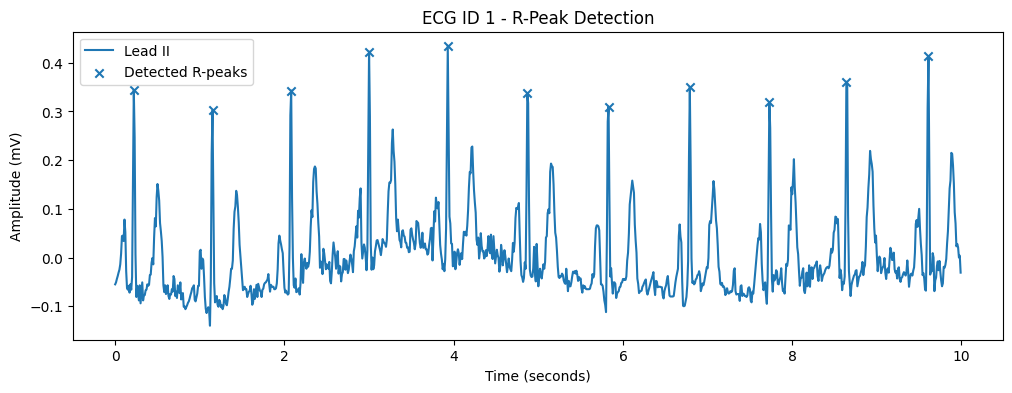

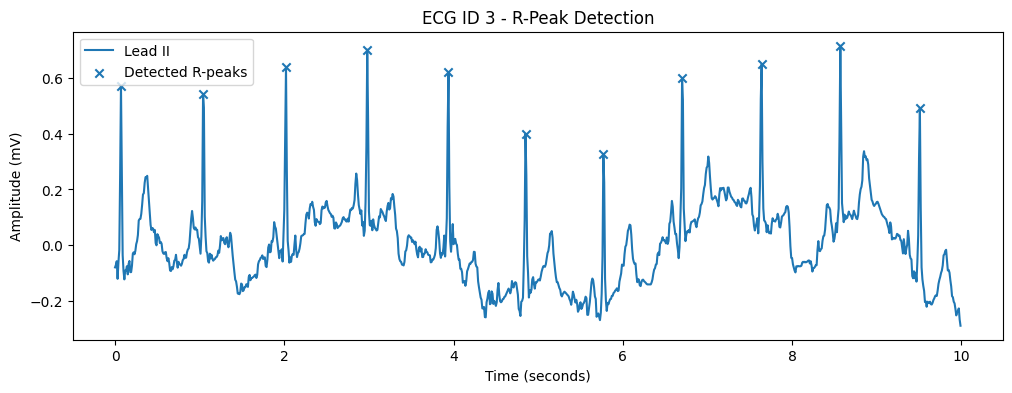

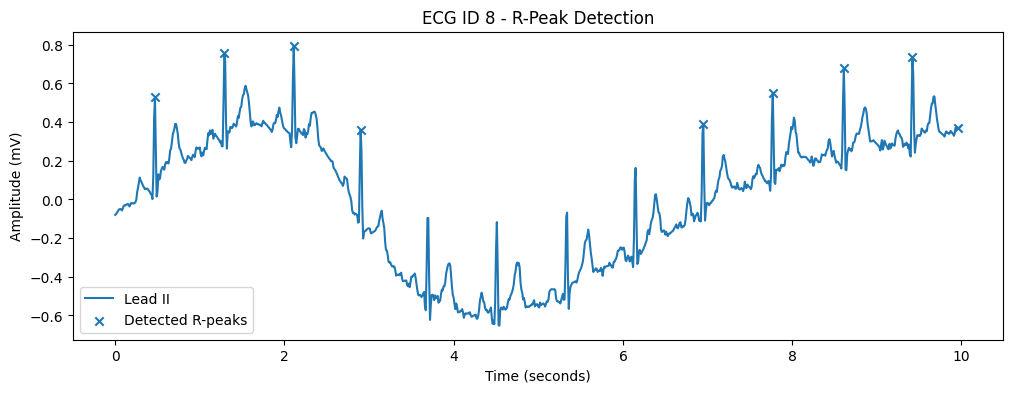

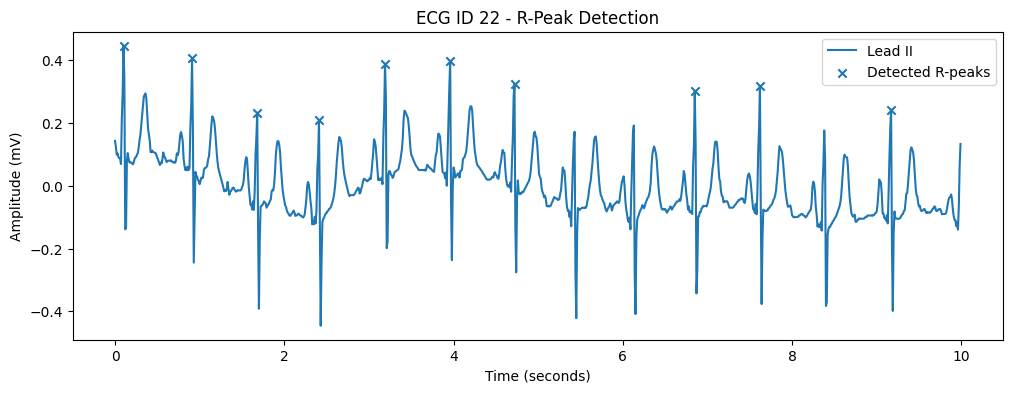

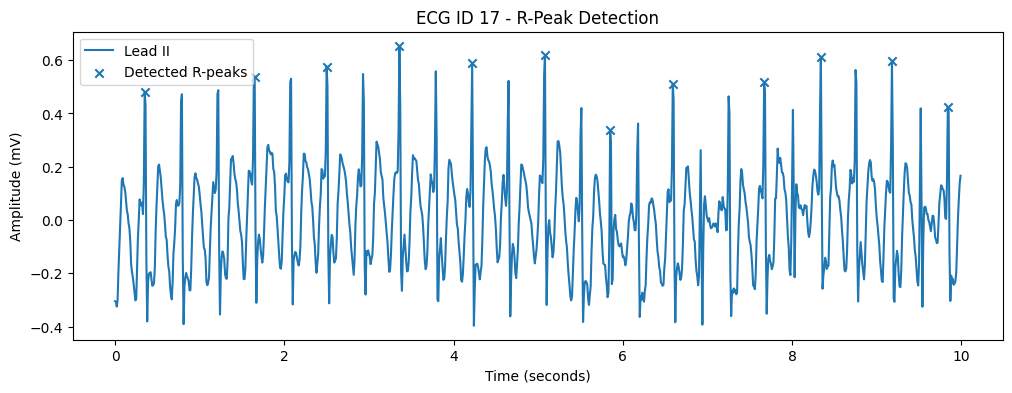

In [19]:
#Plot all 5 ECGs with detected R-peaks
import matplotlib.pyplot as plt
import os
# Create figures folder if it does not already exist
os.makedirs("figures", exist_ok=True)

for ecg_id in selected_ids:

    record = records[ecg_id]
    peaks = peak_results[ecg_id]

    # Get Lead II
    lead_ii_index = record.sig_name.index("II")
    signal = record.p_signal[:, lead_ii_index]

    # Convert samples to seconds
    time = np.arange(len(signal)) / record.fs

    plt.figure(figsize=(12, 4))

    # Plot ECG
    plt.plot(time, signal, label="Lead II")

    # Mark detected R-peaks
    plt.scatter(
        peaks / record.fs,
        signal[peaks],
        marker="x",
        label="Detected R-peaks"
    )

    plt.title(f"ECG ID {ecg_id} - R-Peak Detection")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude (mV)")
    plt.legend()

    plt.savefig(
    f"figures/ecg_{ecg_id}_rpeak_detection.png",
    dpi=300,
    bbox_inches="tight"
)
    plt.show()

### Observation of R-Peak Detection

The fixed R-peak detection parameters worked relatively well for ECG 1 and ECG 3, where the detected peaks were regularly located on prominent positive peaks. However, the method was less consistent for the abnormal ECG records.

ECG 8 showed a long interval where several possible QRS complexes were not detected, likely because their amplitudes did not reach the fixed threshold. ECG 22 also showed incomplete detection because some QRS complexes had different waveform shapes and amplitudes. ECG 17 had a more complex and rapidly changing waveform, making simple threshold-based peak detection less reliable.

These results show that a single fixed height threshold may work for some ECG signals but may not generalize well to ECGs with different amplitudes, morphologies, or rhythms.

In [ ]:
#Add a success/failure column to the comparison table
results_df["Detection Quality"] = [
    "Good",
    "Good",
    "Poor - missed peaks",
    "Incomplete",
    "Potentially unreliable"
]

results_df

## Failure Case Analysis

ECG 8 showed the clearest limitation of the fixed R-peak detection method.

Using the same parameters (`height=0.2`, `distance=50`), several possible QRS complexes between approximately 3 and 6.5 seconds were not detected. This created a large gap between detected peaks and caused the peak-count heart rate estimate (54 bpm) to differ substantially from the median R-R estimate (73.2 bpm).

The likely reason is that the ECG amplitude and baseline changed over time, so some true cardiac peaks did not reach the fixed positive height threshold of 0.2 mV.

This demonstrates that a fixed threshold may work well for some ECG recordings but may fail when waveform amplitude, morphology, or baseline varies between patients.

A more robust method could use adaptive thresholds, signal filtering, or a dedicated QRS detection algorithm instead of one fixed height threshold.

## Conclusion

The same R-peak detection parameters were tested on five different PTB-XL ECG records.

The method worked relatively well for the two normal ECG examples, but performance was less consistent for several abnormal ECGs. ECG 8 showed a clear failure case, while ECG 22 and ECG 17 also demonstrated limitations of simple fixed-threshold detection.

These results show that ECG signals vary between patients and conditions, so one fixed threshold may not generalize well to all recordings. More adaptive signal-processing methods would be needed for reliable automated ECG analysis.